In [3]:
import os, sys, time
import numpy as np
import pandas as pd
import pickle as pk
from brian2 import *
import seaborn as sns
from random import randint
from itertools import *
import scipy.interpolate as itp
from multiprocessing import Pool, Process

sys.path.append('/home/nishant/lab/MFB/scripts')
sys.path.append('/home/nishant/lab/MFB/steps')
sys.path.append('/home/nishant/lab/scripts')
from analysis import *
from peaks import *
from misc import *

plt.style.use('dark_background')

## MCell analysis

In [2]:
syt7KO = 'syt7KO'
dataPath = "/media/nishant/4tb/output/MFB/control_unsatBuffer/"
resultPath = "/home/nishant/lab/MFB/results/syt7KO_unsatBuffer/"

dirs = [a for a in getDirs(resultPath, sstr='nVDCC') if "ISI_20" in a]
dirs.sort(key=natural_keys)
tempdirs = np.array(dirs)[:]

for i,d in enumerate(tempdirs): print(i, d)

0 nVDCC_3_dVDCC_60_nAZ_7_RRP_20_ISI_20_nAP_10
1 nVDCC_3_dVDCC_60_nAZ_17_RRP_10_ISI_20_nAP_10
2 nVDCC_3_dVDCC_80_nAZ_27_RRP_35_ISI_20_nAP_10
3 nVDCC_4_dVDCC_60_nAZ_9_RRP_5_ISI_20_nAP_10
4 nVDCC_4_dVDCC_80_nAZ_17_RRP_35_ISI_20_nAP_10
5 nVDCC_4_dVDCC_80_nAZ_27_RRP_20_ISI_20_nAP_10
6 nVDCC_4_dVDCC_80_nAZ_29_RRP_15_ISI_20_nAP_10
7 nVDCC_7_dVDCC_80_nAZ_7_RRP_10_ISI_20_nAP_10
8 nVDCC_7_dVDCC_100_nAZ_7_RRP_30_ISI_20_nAP_10
9 nVDCC_7_dVDCC_100_nAZ_29_RRP_5_ISI_20_nAP_10
10 nVDCC_7_dVDCC_140_nAZ_27_RRP_15_ISI_20_nAP_10
11 nVDCC_7_dVDCC_160_nAZ_19_RRP_40_ISI_20_nAP_10
12 nVDCC_7_dVDCC_160_nAZ_27_RRP_20_ISI_20_nAP_10
13 nVDCC_8_dVDCC_100_nAZ_7_RRP_20_ISI_20_nAP_10
14 nVDCC_8_dVDCC_100_nAZ_19_RRP_5_ISI_20_nAP_10
15 nVDCC_8_dVDCC_140_nAZ_17_RRP_20_ISI_20_nAP_10
16 nVDCC_8_dVDCC_200_nAZ_29_RRP_20_ISI_20_nAP_10
17 nVDCC_8_dVDCC_220_nAZ_27_RRP_30_ISI_20_nAP_10
18 nVDCC_9_dVDCC_120_nAZ_9_RRP_20_ISI_20_nAP_10
19 nVDCC_9_dVDCC_140_nAZ_9_RRP_30_ISI_20_nAP_10
20 nVDCC_9_dVDCC_140_nAZ_19_RRP_10_ISI_20_nAP_10

### Averaging Calcium Data

In [ ]:
fname = "ca.dat" 
for dir in tq(tempdirs[25:26], desc=f'AVG ({fname}):'):
    #avg_dat(dataPath, resultPath, dir, fname, cores=20)
    try:
        avg_dat(dataPath, resultPath, dir, fname, cores=20)
        print(dir)
    except:
        print(f'Error in {dir}')

In [ ]:
fname = "ca.dat" 
jobInfo = list(product([dataPath], [resultPath], tempdirs[:], [fname]))

p = Pool(19)
p.starmap(avg_dat, jobInfo)
p.close()

### Generate AZ Calcium Concentration

In [ ]:
#CaConc(resultPath, tempdirs[1], step=10)

arg = list(product([resultPath], tempdirs[25:26]))
p = Pool(18)
p.starmap(CaConc, arg);
p.close()

## Plot MCell data

In [ ]:
#tempdirs = ['nVDCC_9_dVDCC_120_nAZ_7']
def plotCa(dir):
    CaGlobal = np.genfromtxt(os.path.join(resultPath,dir,'ca.dat'), unpack=True)
    CaAZ = np.genfromtxt(os.path.join(resultPath,dir,'CaConc.dat'), unpack=True)

    f, ax = plt.subplots(2, sharex=True, figsize=(15,8))
    f.subplots_adjust(hspace=0.0)

    ax[0].plot(CaGlobal[0]*1000, CaGlobal[1]*2.024e-4)
    ax[0].set_ylabel('Global Ca ($\mu$M)')
    ax[0].set_title(dir)

    for i in range(1,3):#len(CaAZ)+1):
        ax[1].plot(CaAZ[0]*1000, CaAZ[i], label="AZ_{:d}".format(i))

    #ax[1].set_xlim(0, 5)
    ax[1].set_ylabel("$[Ca]$ ($\mu$M)")
    ax[1].legend(bbox_to_anchor=(1, 1.2), loc='upper left', ncol=2)
    #ax[1].set_ylim(0,0.4)
    plt.show()
    
for dir in tempdirs[:1]:
    plotCa(dir)

## AZ simulation in STEPS

In [4]:
from MFB_model import *
mdl, sim, r = get_MFB_model(syt7KO=syt7KO)

In [5]:
def runAZTrials(CaData, RRP):
    vesData = {}

    resAZ, vesRel = simAZ(CaData[0], CaData[1], sim, r, RRP=RRP)
    vesRelSync  = np.sum(vesRel[:,:3], axis=1)
    vesRelAsync = np.sum(vesRel[:,3:-2], axis=1)
    vesRelSpont  = vesRel[:,-1]

    vesRelTot = np.sum(vesRel, axis=1)
    #print(vesRelSync, vesRelAsync, vesRelSpont)

    pksSync = detect_peaks(vesRelSync, edge='rising', show=False)
    pksAsync = detect_peaks(vesRelAsync, edge='rising', show=False)
    pksSpont = detect_peaks(vesRelSpont, edge='rising', show=False)

    vesData.update({'sync' : list(CaData[0,pksSync])})
    vesData.update({'async': list(CaData[0,pksAsync])})
    vesData.update({'spont': list(CaData[0,pksSpont])})

    return vesData, resAZ

In [6]:
def getVesRel(dir, RRP, resultPath, fname='CaConc.dat', trials=2000, pools=False, syt7KO=syt7KO):
    nAZ = int(getSimInfo(dir, 'nAZ'))
    
    CaFile = os.path.join(resultPath, dir, fname)
    try:
        CaData = np.genfromtxt(CaFile, unpack=True)
    except:
        shutil.copy(CaFile.replace('syt7KO', 'control'), CaFile)
        shutil.copy(CaFile.replace('syt7KO', 'control').replace('CaConc', 'ca'), 
                    CaFile.replace('CaConc', 'ca'))
        
    CaData = np.genfromtxt(CaFile, unpack=True) # in uM
    
    if pools:
        p = Pool(pools)
    else:
        p = Pool()
        
    vesData = {}
    desc = str([int(a) for a in re.findall(r'\d+', dir)[:-1]])
    for iCa in tq(range(1,nAZ+1), desc=desc):
        info = product([CaData[(0,iCa),:]], [RRP]*trials)
        data = np.array(p.starmap(runAZTrials, info))
        
        vesSync  = [a['sync'] for a in data[:,0]]
        vesAsync = [a['async'] for a in data[:,0]]
        vesSpont = [a['spont'] for a in data[:,0]]
        vesData.update({f'AZ{iCa}': {'sync': vesSync, 'async':vesAsync, 'spont':vesSpont}})
        
        resAZ = data[:,1]
        AZstates = np.mean(resAZ, axis=0)
        
        if syt7KO: fAZ = os.path.join(resultPath, dir, f'AZ_{iCa}_syt7KO.dat')
        else: fAZ = os.path.join(resultPath, dir, f'AZ_{iCa}.dat')
        AZdata = np.hstack((np.array([CaData[0]]).T, AZstates))
        np.savetxt(fAZ, AZdata, fmt=['%0.5f']+['%0.4f']*18, delimiter="\t")
        
    #print(vesData)
    p.close()
    return vesData

In [ ]:
for dir in tq(tempdirs[7:8]):
    try:
        nVDCC, dVDCC, nAZ, RRP = [int(getSimInfo(dir, key)) for key in ['nVDCC', 'dVDCC', 'nAZ', 'RRP']]
        #print(nVDCC, dVDCC, nAZ, RRP)

        if not os.path.exists(os.path.join(resultPath,dir)):
            os.makedirs(os.path.join(resultPath,dir))

        vesData = getVesRel(dir, RRP=RRP, resultPath=resultPath, trials=50, pools=35)

        if syt7KO:
            with open(os.path.join(resultPath, dir, 'vesData_syt7KO.dat'),"wb") as outfile:
                pk.dump(vesData, outfile)

        else:
            with open(os.path.join(resultPath, dir, 'vesData.dat'),"wb") as outfile:
                pk.dump(vesData, outfile)

        relStat(dir, resultPath, resample=1000, syt7KO=syt7KO)
    except:
        print(f'Error in {dir}')

## Get Vesicle Release Statistics

In [ ]:
for dir in tq(tempdirs[7:8]):
    #relStat(d, resultPath, resample=1000)
    try:
        relStat(dir, resultPath, resample=1000, syt7KO=syt7KO)
    except:
        print(f'Error in {d}')

In [ ]:
### parallely
jobInfo = list(product(tempdirs[:], [resultPath], [1000]))
#print(info)

p = Pool(20)
p.starmap(relStat, jobInfo)
p.close()

## EPSC calculations

In [ ]:
for d in dirs[:]:
    resultDir = os.path.join(resultPath, d)
    tpoints, avgEPSC = getAvgEPSC(resultDir, 'vesData.dat')
    fepsc = os.path.join(resultPath, d, 'epsc.dat')
    np.savetxt(fepsc, np.array([tpoints, avgEPSC]).T, fmt=['%0.5f']+['%0.2f'], delimiter="\t")
    #plt.plot(tpoints, avgEPSC)

    allapTimes = {}
    for APth in range(75, 201, 25):
        apTimes = getAPTimes(resultDir, 'vesData.dat', APth=APth)
        allapTimes.update({APth: apTimes})
    with open(os.path.join(resultPath, d, 'apTimes.dat'), "wb") as outfile:
        pk.dump(allapTimes, outfile)
    print(d)

## AP generation and EPSC calculations

In [5]:
%%time
sigma = 0.2 # noise amplitude
tstep = 0.1 # ms
for d, ttt in product(dirs, ['']):
    resultDir = os.path.join(resultPath, d)
    indices, vesreltimes, nCA3 = getVesInput(resultDir, ttt=ttt, delta=tstep/1000)

    start_scope()
    defaultclock.dt = tstep*ms

    CA3inp = SpikeGeneratorGroup(nCA3, indices, vesreltimes*second)
    #nCA3 = 4; CA3inp = SpikeGeneratorGroup(nCA3, indices[:35], vesreltimes[:35]*second)

    ## CA3 neuron
    V_L = -60.0*mV
    V_thr = -42.0*mV
    V_reset = -65.0*mV

    Cm = 0.025*nF # membrane capacitance
    gm = 0.5*nS  # membrane leak
    tau_rp = 5.0*ms # refractory period 

    gmax_ampa = 1*nsiemens # max AMPA conductance
    tau_g_ampa = 10*ms
    tau_d = 50*ms # desensitisation
    
    tau_nt = 1*ms
    
    A1, A2 = 5/(mM*ms), 0.18/ms
    g_gabaA = 1*nsiemens
    V_gabaA = -85*mV

    B1, B2 = 0.09/(mM*ms), 0.0012/ms
    K1, K2 = 0.18/ms, 0.034/ms
    g_gabaB = 3*nsiemens
    V_gabaB = -95*mV


    eqnCA3 = '''
    dv/dt = (- gm*(v - V_L) - I_ampa - I_gabaA - I_gabaB) / Cm : volt (unless refractory)
    I_ampa = gmax_ampa*g_ampa*d*v : amp
    dg_ampa/dt = -g_ampa/tau_g_ampa : 1
    dd/dt = (1-d)/tau_d : 1

    I_gabaA = g_gabaA*f_gabaA*(v - V_gabaA): amp
    df_gabaA/dt = A1*nt*(1 - f_gabaA) - A2*f_gabaA : 1

    I_gabaB = g_gabaB * G**4/(G**4+100)*(v - V_gabaB): amp
    df_gabaB/dt = B1*nt*(1 - f_gabaB) - B2*f_gabaB : 1
    dG/dt = K1*f_gabaB - K2*G: 1

    nt : mM
    '''

    CA3 = NeuronGroup(nCA3, eqnCA3, threshold='v > V_thr', reset='v = V_reset', 
                      refractory=tau_rp, method='euler')
    CA3.v = V_L
    CA3.d = 1
    
    ## DG input spikes for interneurons
    simInfo = getSimInfo(d)
    ISI, nAP = int(simInfo['ISI']), int(simInfo['nAP'])
    try: bISI, nB = int(simInfo['bISI']), int(simInfo['nB'])
    except KeyError: bISI, nB = 0, 1
    stimTimes = np.sort([1.5 + na*ISI + nb*bISI for na,nb in product(range(nAP), range(nB))])/1000
    sptimes = np.array(stimTimes)*second
    
    DG = SpikeGeneratorGroup(1, np.zeros(sptimes.shape), sptimes)
    
    ## Inhibitory Interneuron
    Cm_in = 0.1*nF # membrane capacitance
    gm_in = 4.0*nS # membrane leak
    tau_rp_in = 1*ms # refractory period
    Vin_rest = -57.0*mV
    Vin_thr, Vin_reset = -50.0*mV, -60.0*mV
    gInmax_ampa = 5*nS
    tau_gIn_ampa = 2*ms

    eqnIn = '''
    dv/dt = (- gm_in*(v - Vin_rest) - I_ampa)/Cm_in + sigma*sqrt(1/(1*ms))*xi*mV: volt (unless refractory)
    I_ampa = gInmax_ampa*gIn_ampa*v : amp
    dgIn_ampa/dt = -gIn_ampa/tau_gIn_ampa : 1
    '''
    
    nIn = 1000
    In = NeuronGroup(nIn, eqnIn, threshold='v > Vin_thr', reset='v = Vin_reset',
                       refractory=tau_rp_in, method='euler')
    In.v = '-60*mV + rand()*10*mV'
    
    ### Synapses
    on_preCA3 = 'g_ampa += 1; d -= 0*d'
    S_CA3inp_CA3 = Synapses(CA3inp, CA3, on_pre=on_preCA3)
    S_CA3inp_CA3.connect('i==j')
    
    on_preIn = 'gIn_ampa += 1'
    S_DG_In = Synapses(DG, In, delay=0.1*ms, on_pre=on_preIn)
    S_DG_In.connect(i=0, j=range(nIn))
    
    ## In ---> CA3 synapse
    eqnSIn = '''
    dnT/dt = -nT/tau_nt: mM (clock-driven)
    nt_post = nT : mM (summed) '''
    
    kk = 10 # average number of inputs a CA3 neuron receives
    S_In_CA3 = Synapses(In, CA3, model=eqnSIn, method='euler', delay=0.1*ms, on_pre='nT += 0.5*mM')
    S_In_CA3.connect(p=kk/nIn)
    
    ### Monitors
    stMCA3 = StateMonitor(CA3, variables=True, record=True)
    spMCA3 = SpikeMonitor(CA3)
    
    spMinp = SpikeMonitor(CA3inp)
    
    stMIn = StateMonitor(In, variables=True, record=True)
    spMIn = SpikeMonitor(In)

    spMDG = SpikeMonitor(DG)
    
    stMS = StateMonitor(S_In_CA3, variables=True, record=True)

    runt = 210 # ms
    run(runt*ms)
    
    avgEPSC = -np.mean((stMCA3.I_ampa + stMCA3.I_gabaA + stMCA3.I_gabaB)/pamp, axis=0)
    fepsc = os.path.join(resultDir, ttt+'epsc.dat')
    np.savetxt(fepsc, np.array([stMCA3.t/second, avgEPSC]).T, fmt=['%0.5f']+['%0.2f'], delimiter="\t")

    apTimes = [a/second for a in list(spMCA3.spike_trains().values())]
    with open(os.path.join(resultDir, ttt+'apTimes.dat'), "wb") as outfile:
        pk.dump(apTimes, outfile)

CPU times: user 4min 12s, sys: 25.7 s, total: 4min 38s
Wall time: 4min 43s


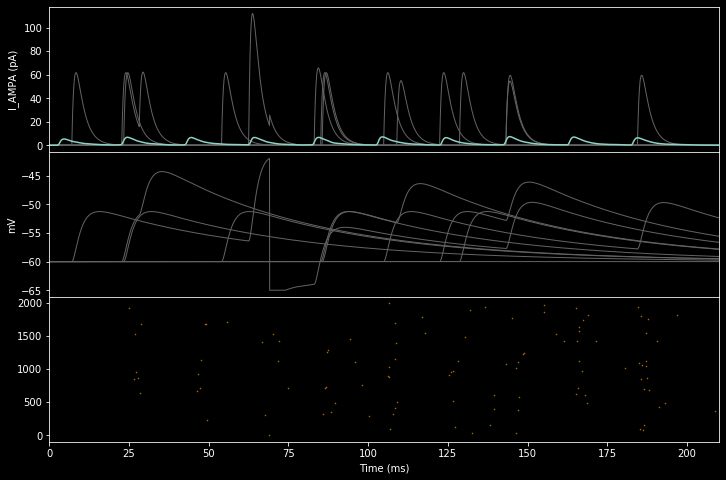

In [5]:
f, ax = plt.subplots(3, sharex=True, figsize=(12,8))
f.subplots_adjust(wspace=0., hspace=0.)
lw = 1

for i in range(10):
    ax[0].plot(stM.t/ms, -stM.I_AMPA[i]/pamp, color=cpall[-1], lw=lw, label='I_AMPA')
    ax[1].plot(stM.t/ms, stM.v[i]/mV, color=cpall[-1], lw=lw, label='v')
ax[0].plot(stM.t/ms, avgEPSC, label='I_AMPA')
ax[0].set_ylabel('I_AMPA (pA)')
ax[1].set_ylabel('mV')
ax[0].set_xlim(0,runt/ms)
#ax[0].legend()

ax[2].plot(spM.t/ms, spM.i, '.k', color=cpall[2], ms=1)
ax[2].set_xlabel('Time (ms)');

## Extra Stuff